In [114]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

Load Dataset

In [115]:
df = pd.read_csv("/bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [116]:
df.shape
df.columns
df['y'].value_counts()

,count
y,
no,3668
yes,451


Checking for explict/implcit missing variables

In [117]:
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [118]:
(df == "unknown").sum()

,0
age,0
job,39
marital,11
education,167
default,803
housing,105
loan,105
contact,0
month,0
day_of_week,0


Plots

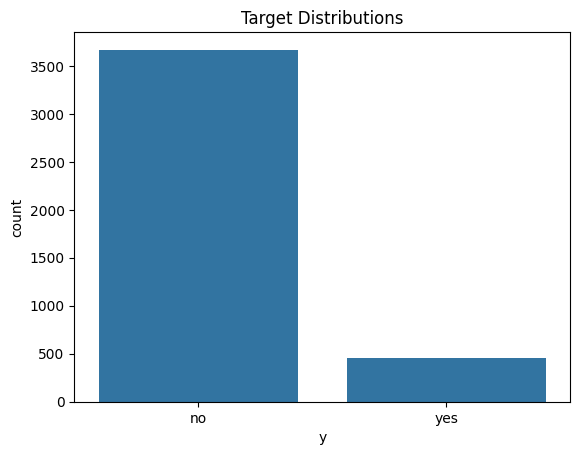

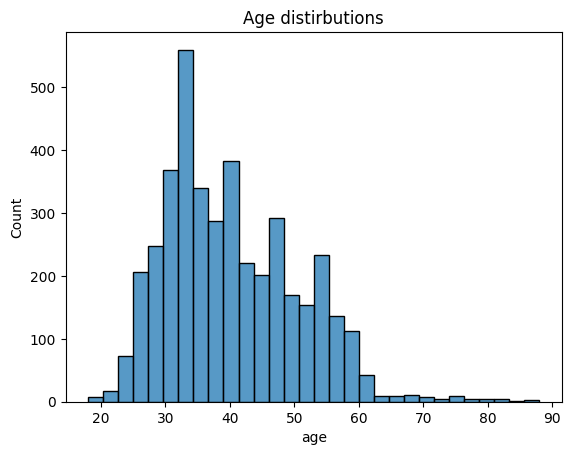

<function matplotlib.pyplot.show(close=None, block=None)>

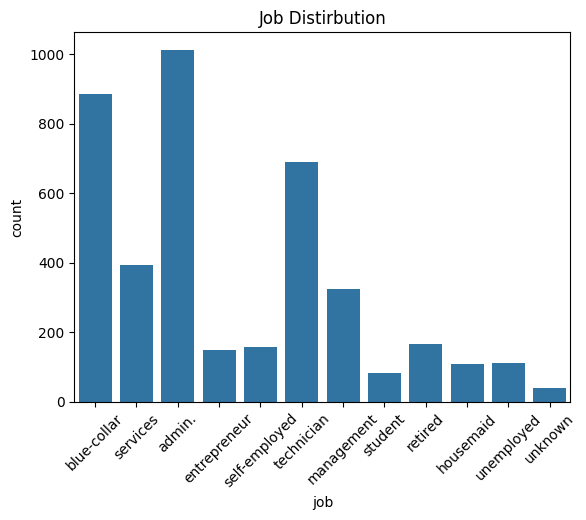

In [119]:
sns.countplot(x='y', data=df)
plt.title("Target Distributions")
plt.show()

sns.histplot(df['age'], bins=30)
plt.title("Age distirbutions")
plt.show()

sns.countplot(x='job', data=df)
plt.xticks(rotation=45)
plt.title("Job Distirbution")
plt.show

Defining X and Y variables

In [120]:
X =df.drop('y', axis=1)
y = df['y']

In [121]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.890507
yes,0.109493


Handling Data Leakage

In [122]:
X = X.drop('duration', axis=1)
X.shape

(4119, 19)

Finding Categorical and Numerical Columns

In [123]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns
categorical_cols, numerical_cols

(Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome'],
       dtype='object'),
 Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='object'))

Train/Validation/Test split

In [124]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)


In [125]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("tes:", X_test.shape)


Train: (2883, 19)
Validation: (618, 19)
tes: (618, 19)


Using One-Hot Encoding for categorical columns

In [126]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_val_cat = encoder.transform(X_val[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

Scaling the numerical columns

In [127]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_val_num = scaler.transform(X_val[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

Combining numerical and categorical columns

In [128]:
X_train_final = np.hstack((X_train_num, X_train_cat))
X_val_final = np.hstack((X_val_num, X_val_cat))
X_test_final = np.hstack((X_test_num, X_test_cat))

In [129]:
print("X_train_final:", X_train_final.shape)
print("X_val_final:", X_val_final.shape)
print("X_test_final:", X_test_final.shape)

X_train_final: (2883, 62)
X_val_final: (618, 62)
X_test_final: (618, 62)


Handling class imbalance

In [130]:
print("Training distribution before resampling:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

Training distribution before resampling:
y
no     2567
yes     316
Name: count, dtype: int64
y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64


In [131]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_final, y_train)

In [132]:
print("Training distribution after resampling:")
print(y_train_resampled.value_counts())
print(y_train_resampled.value_counts(normalize=True))

Training distribution after resampling:
y
no     2567
yes    2567
Name: count, dtype: int64
y
no     0.5
yes    0.5
Name: proportion, dtype: float64


Training the logistic regression Model

In [133]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000, random_state=42)

Validation/Test predictions and confusion table

In [134]:
y_val_pred = model.predict(X_val_final)

In [135]:
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val,  y_val_pred, pos_label='yes'))
print("Recall:", recall_score(y_val,  y_val_pred, pos_label='yes'))

Accuracy: 0.8317152103559871
Precision: 0.3524590163934426
Recall: 0.6323529411764706


In [136]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))


Confusion Matrix:
[[471  79]
 [ 25  43]]

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.86      0.90       550
         yes       0.35      0.63      0.45        68

    accuracy                           0.83       618
   macro avg       0.65      0.74      0.68       618
weighted avg       0.88      0.83      0.85       618



In [137]:
y_test_pred = model.predict(X_test_final)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred, pos_label='yes'))
print("Test Recall:", recall_score(y_test, y_test_pred, pos_label='yes'))


Test Accuracy: 0.8106796116504854
Test Precision: 0.2916666666666667
Test Recall: 0.5223880597014925


In [138]:
print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))


Test Confusion Matrix:
[[466  85]
 [ 32  35]]

Test Classification Report:
              precision    recall  f1-score   support

          no       0.94      0.85      0.89       551
         yes       0.29      0.52      0.37        67

    accuracy                           0.81       618
   macro avg       0.61      0.68      0.63       618
weighted avg       0.87      0.81      0.83       618

